phân loại mức độ hài lòng của khách hàng từ đánh giá khách sạn

In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('drive/MyDrive/Colab Notebooks/BTL_hocmay/hotel-classification-dataset.csv')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob

from sklearn.preprocessing import LabelEncoder, StandardScaler, MultiLabelBinarizer
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve
)
from collections import Counter

Kích thước dữ liệu: (290315, 17)


,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Tags,days_since_review,lat,lng,Reviewer_Score
0,44 Grosvenor Square Westminster Borough London...,806,5/19/2017,7.8,Millennium Hotel London Mayfair,Qatar,Carpets and HVAC are dusty,6,3117,Very good location,4,9,"[' Leisure trip ', ' Family with young childre...",76 days,51.510574,-0.150995,Intermediate_Reviewer_Score
1,Bryanston Street Marble Arch Westminster Borou...,908,3/29/2016,8.5,Amba Hotel Marble Arch,United Kingdom,Nothing,2,3980,Service and the room,5,1,"[' Leisure trip ', ' Group ', ' Standard Twin ...",492 day,51.514400,-0.156551,High_Reviewer_Score
2,Via Senigallia 6 20161 Milan Italy,904,8/23/2016,8.1,Hotel Da Vinci,Belgium,City tax should be considered while booking b...,14,16670,Breakfast is quite rich it is not easy to fin...,19,23,"[' Leisure trip ', ' Couple ', ' Double Room '...",345 day,45.533137,9.171102,Intermediate_Reviewer_Score
3,17 rue de l Arcade 8th arr 75008 Paris France,230,7/14/2016,8.6,H tel Bedford,United Kingdom,Nothing,2,1703,Everything,3,6,"[' Leisure trip ', ' Family with older childre...",385 day,48.872059,2.323680,High_Reviewer_Score
4,57 59 Welbeck Street Westminster Borough Londo...,241,5/22/2017,7.5,Holiday Inn London Oxford Circus,Israel,At first we got a very small room in the end ...,58,1287,The staff was helpful changing our room Centr...,17,3,"[' Leisure trip ', ' Couple ', ' Double Room '...",73 days,51.516843,-0.149557,Intermediate_Reviewer_Score



Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290315 entries, 0 to 290314
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   Hotel_Address                               290315 non-null  object 
 1   Additional_Number_of_Scoring                290315 non-null  int64  
 2   Review_Date                                 290315 non-null  object 
 3   Average_Score                               290315 non-null  float64
 4   Hotel_Name                                  290315 non-null  object 
 5   Reviewer_Nationality                        290315 non-null  object 
 6   Negative_Review                             290315 non-null  object 
 7   Review_Total_Negative_Word_Counts           290315 non-null  int64  
 8   Total_Number_of_Reviews                     290315 non-null  int64  
 9   Positive_Review                             290315

,Additional_Number_of_Scoring,Average_Score,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,lat,lng
count,290315.000000,290315.00000,290315.000000,290315.000000,290315.000000,290315.000000,288491.000000,288491.000000
mean,496.481987,8.39744,18.531943,2739.497680,17.814126,7.174979,49.436561,2.834710
std,499.005247,0.54809,29.662069,2315.945964,21.780053,11.054209,3.468708,4.592047
min,1.000000,5.20000,0.000000,43.000000,0.000000,1.000000,41.328376,-0.369758
25%,168.000000,8.10000,2.000000,1158.000000,5.000000,1.000000,48.214277,-0.143372
50%,341.000000,8.40000,9.000000,2130.000000,11.000000,3.000000,51.499981,0.019886
75%,641.000000,8.80000,23.000000,3613.000000,22.000000,8.000000,51.516288,4.834443
max,2682.000000,9.80000,403.000000,16670.000000,395.000000,315.000000,52.400181,16.429233



Số lượng missing theo cột:


,0
lat,1824
lng,1824
Hotel_Address,0
Additional_Number_of_Scoring,0
Review_Date,0
Reviewer_Nationality,0
Negative_Review,0
Average_Score,0
Hotel_Name,0
Total_Number_of_Reviews,0



Phân bố nhãn:


,count
Reviewer_Score,
High_Reviewer_Score,165639
Intermediate_Reviewer_Score,112186
Low_Reviewer_Score,12490


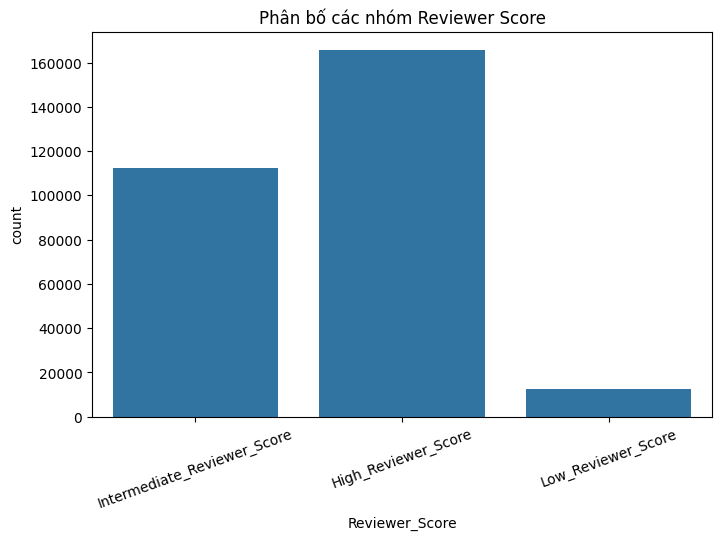

In [ ]:
print("Kích thước dữ liệu:", df.shape)
display(df.head())

print("\nThông tin dữ liệu:")
df.info()

print("\nThống kê mô tả:")
display(df.describe())

print("\nSố lượng missing theo cột:")
display(df.isnull().sum().sort_values(ascending=False).head(20))

print("\nPhân bố nhãn:")
display(df['Reviewer_Score'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(x=df['Reviewer_Score'])
plt.title("Phân bố các nhóm Reviewer Score")
plt.xticks(rotation=20)
plt.show()

In [ ]:
duplicate_count = df.duplicated().sum()
print("Số dòng trùng nhau:", duplicate_count)

Số dòng trùng nhau: 174


In [ ]:
# Xóa bỏ các dòng trùng lặp
df.drop_duplicates(keep='first', inplace=True)

In [ ]:
# Xử lý các giá trị thiếu
numeric_cols = df.select_dtypes(include=['number']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

xử lí ngoại lai bằng IQR giúp phát hiện các giá trị quá bất thường dựa trên khoảng tứ phân vị. Cách này phù hợp với dữ liệu có phân phối lệch và giúp giảm ảnh hưởng của giá trị quá lớn hoặc quá nhỏ.

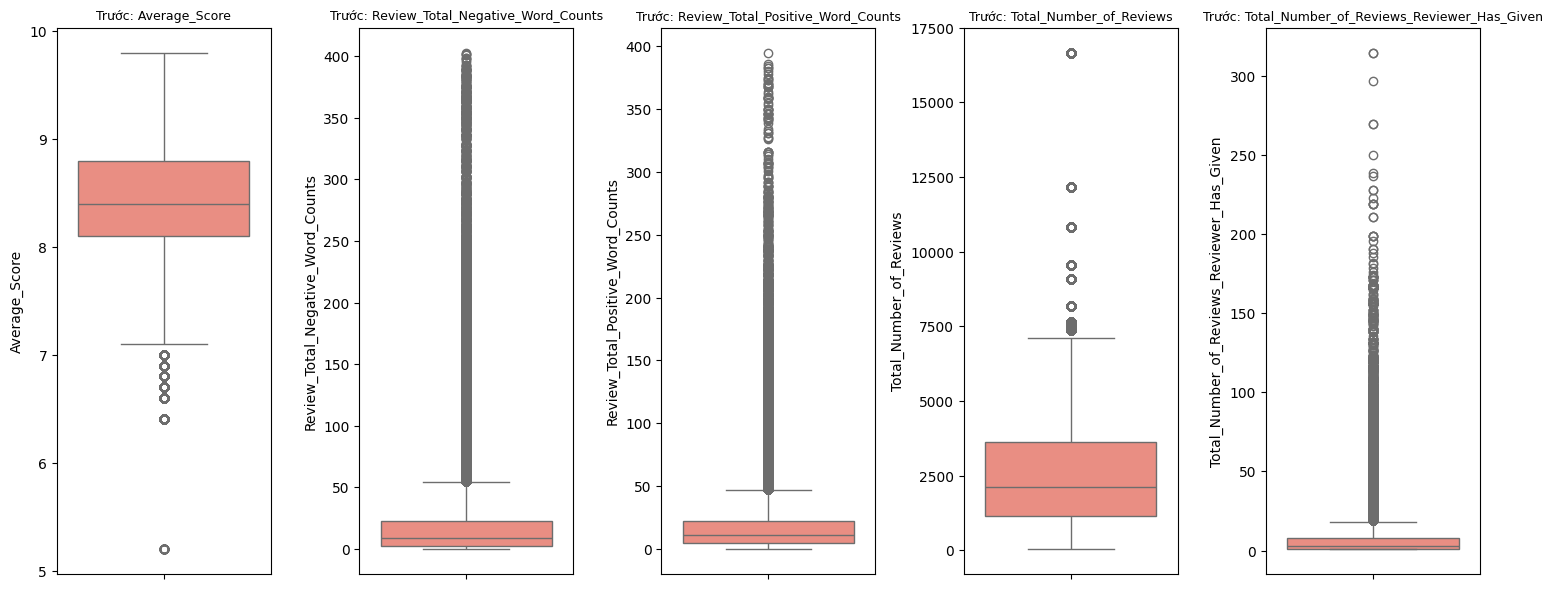

Số dòng trước khi lọc: 290141
Số dòng sau khi lọc: 213557


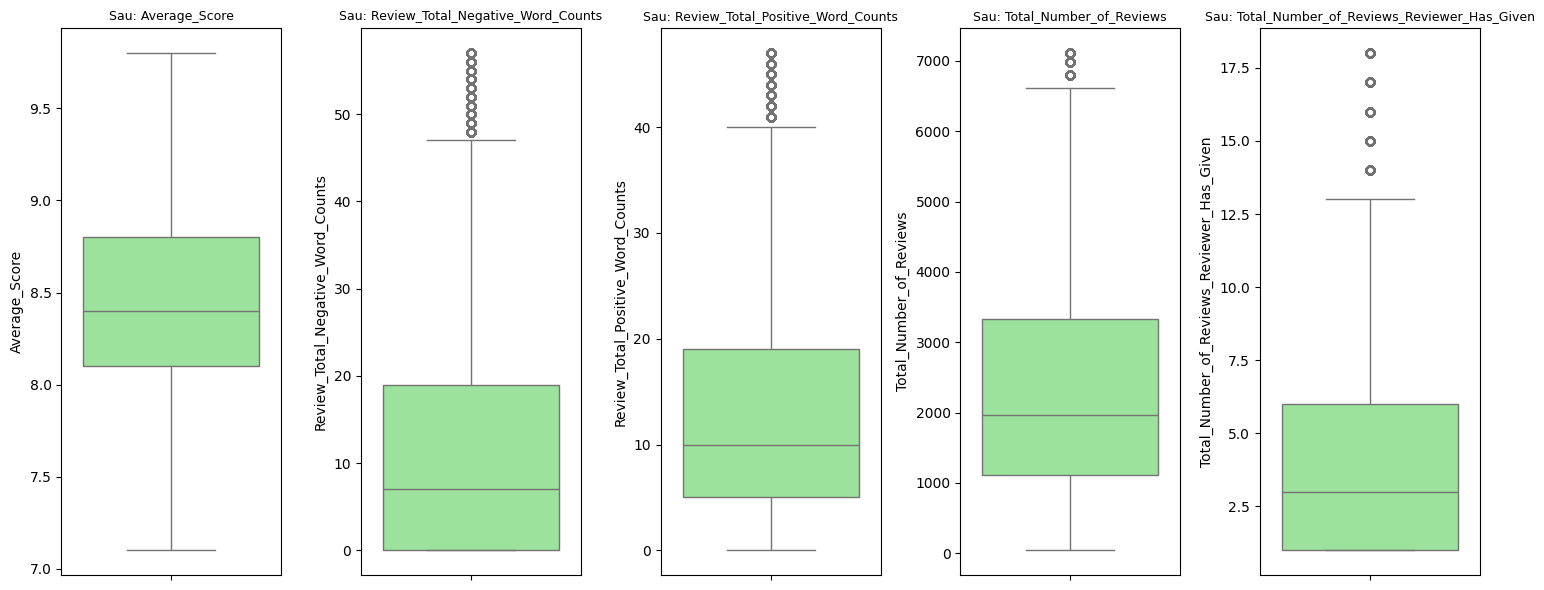

In [ ]:
##xử lí ngoại lai
# Danh sách cột cần xử lý ngoại lai
outlier_cols = [
    'Average_Score',
    'Review_Total_Negative_Word_Counts',
    'Review_Total_Positive_Word_Counts',
    'Total_Number_of_Reviews',
    'Total_Number_of_Reviews_Reviewer_Has_Given' #đều là cột số định lượng
]

# Vẽ Boxplot TRƯỚC khi xử lý
plt.figure(figsize=(15, 6))
for i, col in enumerate(outlier_cols):
    if col in df.columns:
        plt.subplot(1, 5, i + 1)
        sns.boxplot(y=df[col], color='salmon')
        plt.title(f'Trước: {col}', fontsize=9)
plt.tight_layout()
plt.show()

# Lọc bỏ ngoại lai bằng IQR
print(f"Số dòng trước khi lọc: {len(df)}")
for col in outlier_cols:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
print(f"Số dòng sau khi lọc: {len(df)}")

#Vẽ Boxplot SAU khi xử lý
plt.figure(figsize=(15, 6))
for i, col in enumerate(outlier_cols):
    if col in df.columns:
        plt.subplot(1, 5, i + 1)
        sns.boxplot(y=df[col], color='lightgreen')
        plt.title(f'Sau: {col}', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# Xử lý ngày tháng
df['Review_Date'] = pd.to_datetime(df['Review_Date'])
df['Review_Month'] = df['Review_Date'].dt.month
df['Review_Year'] = df['Review_Date'].dt.year

Vì ngày tháng ở dạng gốc không thể đưa trực tiếp vào mô hình.Hai đặc trưng này có thể phản ánh xu hướng đánh giá theo thời gian.

In [ ]:
# Tính điểm cảm xúc
def get_sentiment(text):
    text = str(text).lower()
    if text in ['no negative', 'nothing', 'none', '']:
        return 0
    return TextBlob(text).sentiment.polarity
df['Negative_Sentiment'] = df['Negative_Review'].apply(get_sentiment)
df['Positive_Sentiment'] = df['Positive_Review'].apply(get_sentiment)

nội dung review dạng văn bản không thể đưa trực tiếp vào các mô hình như Logistic Regression, Decision Tree, Random Forest.

Do đó, bài dùng TextBlob để chuyển văn bản thành điểm cảm xúc

In [ ]:
# Tính độ dài review
df['Total_Review_Length'] = df['Negative_Review'].astype(str).apply(len) + df['Positive_Review'].astype(str).apply(len)

In [ ]:
#xử lí cột tag
df['Tags'] = df['Tags'].apply(lambda x: eval(str(x).strip()))
all_tags = [tag for tags in df['Tags'] for tag in tags]

top_tags = [tag for tag, count in Counter(all_tags).most_common(20)] # Lấy top 20 tags

df['Tags_filtered'] = df['Tags'].apply(lambda tags: [tag if tag in top_tags else 'other' for tag in tags])

mlb = MultiLabelBinarizer()
tags_encoded = mlb.fit_transform(df['Tags_filtered'])
tags_df = pd.DataFrame(tags_encoded, columns=mlb.classes_, index=df.index)
df = pd.concat([df, tags_df], axis=1)

Tags chứa thông tin như loại chuyến đi, số đêm ở lại, đi một mình hay đi cùng gia đình. Đây là thông tin quan trọng có thể ảnh hưởng đến điểm đánh giá.

Vì Tags là dạng danh sách nhiều nhãn, bài dùng MultiLabelBinarizer để chuyển thành nhiều cột nhị phân.

Target
1    127059
0     86498
Name: count, dtype: int64


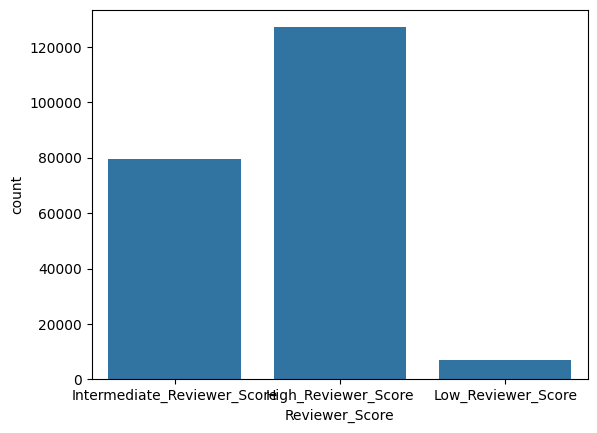

In [ ]:
#gán nhãn
target_mapping = {
    "Low_Reviewer_Score": 0,
    "Intermediate_Reviewer_Score": 0,
    "High_Reviewer_Score": 1
}
df['Target'] = df['Reviewer_Score'].map(target_mapping)
sns.countplot(x=df['Reviewer_Score'])

print(df['Target'].value_counts())


In [ ]:
# Drop cột không cần thiết
cols_to_drop = [
    'Hotel_Address',
    'Negative_Review',
    'Positive_Review',
    'Tags',
    'Tags_filtered',
    'Review_Date',
    'days_since_review',
    'Reviewer_Score',
    'lat',
    'lng',
    'Reviewer_Nationality',
    'Hotel_Name'
]
cols_to_drop = [c for c in cols_to_drop if c in df.columns]

chia và chuẩn hóa

In [ ]:
X = df.drop(columns=cols_to_drop + ['Target'])
y = df['Target']
X.fillna(0, inplace=True) # Điền 0 vào các ô trống còn sót lại
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

#SMOTE tạo thêm mẫu tổng hợp cho lớp thiểu số trong tập train, giúp mô hình học tốt hơn lớp ít dữ liệu.
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# 1. LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

clf_log = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
clf_log.fit(X_train_scaled, y_train_res)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
# 2. Dự đoán
y_pred = clf_log.predict(X_test_scaled)
y_proba = clf_log.predict_proba(X_test_scaled)[:, 1] # Lấy xác suất lớp Tốt

In [ ]:
# 3. Đánh giá chỉ số
print(classification_report(y_test, y_pred))
auc_score = roc_auc_score(y_test, y_proba)
print(f"ROC AUC Score: {auc_score:.4f}")

              precision    recall  f1-score   support

           0       0.70      0.64      0.67     25950
           1       0.77      0.81      0.79     38118

    accuracy                           0.74     64068
   macro avg       0.73      0.73      0.73     64068
weighted avg       0.74      0.74      0.74     64068

ROC AUC Score: 0.8075


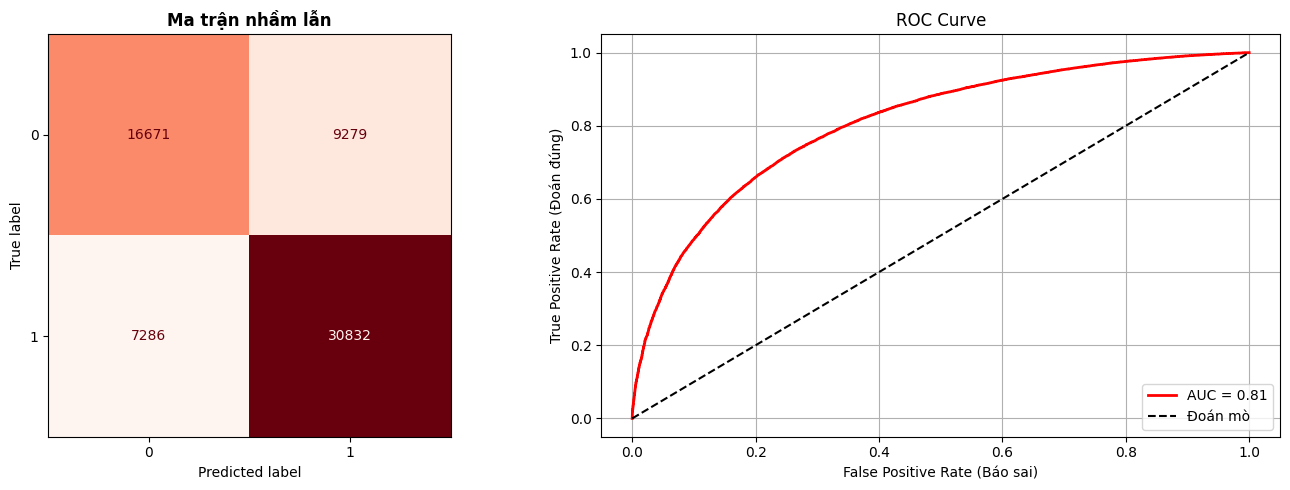

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Ma trận nhầm lẫn
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Reds', ax=ax[0], colorbar=False)
ax[0].set_title("Ma trận nhầm lẫn", fontweight='bold')
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
ax[1].plot(fpr, tpr, label=f'AUC = {auc_score:.2f}', color='red', lw=2)
ax[1].plot([0, 1], [0, 1], 'k--', label='Đoán mò')
ax[1].set_xlabel('False Positive Rate (Báo sai)')
ax[1].set_ylabel('True Positive Rate (Đoán đúng)')
ax[1].set_title('ROC Curve')
ax[1].legend(loc='lower right')
ax[1].grid(True)

plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

           0       0.66      0.71      0.69     25950
           1       0.79      0.75      0.77     38118

    accuracy                           0.74     64068
   macro avg       0.73      0.73      0.73     64068
weighted avg       0.74      0.74      0.74     64068

ROC AUC Score: 0.8045


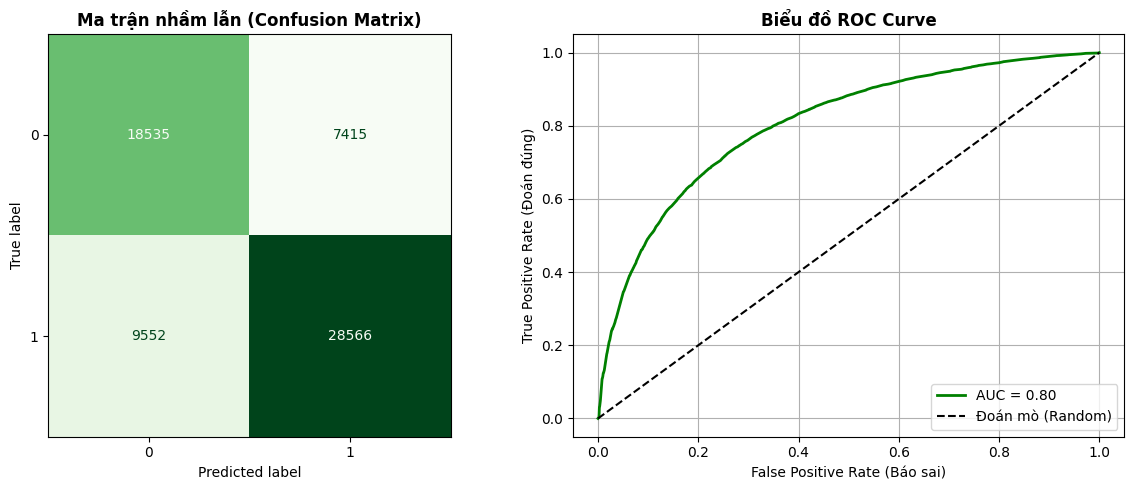

In [ ]:
# MÔ HÌNH 2: DECISION TREE
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# 1. Khởi tạo
clf_tree = DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=10)

# 2. Huấn luyện
clf_tree.fit(X_train_scaled, y_train_res)

# 3. Dự đoán
y_pred_tree = clf_tree.predict(X_test_scaled)
y_proba_tree = clf_tree.predict_proba(X_test_scaled)[:, 1] # Lấy xác suất lớp 1 (Tốt)

# 4. Đánh giá chỉ số
print(classification_report(y_test, y_pred_tree))
auc_score = roc_auc_score(y_test, y_proba_tree)
print(f"ROC AUC Score: {auc_score:.4f}")


fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Hình 1: Ma trận nhầm lẫn
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree, cmap='Greens', ax=ax[0], colorbar=False)
ax[0].set_title("Ma trận nhầm lẫn (Confusion Matrix)", fontweight='bold')

# Hình 2: Đường cong ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_tree)
ax[1].plot(fpr, tpr, label=f'AUC = {auc_score:.2f}', color='green', lw=2)
ax[1].plot([0, 1], [0, 1], 'k--', label='Đoán mò (Random)')
ax[1].set_xlabel('False Positive Rate (Báo sai)')
ax[1].set_ylabel('True Positive Rate (Đoán đúng)')
ax[1].set_title('Biểu đồ ROC Curve', fontweight='bold')
ax[1].legend(loc='lower right')
ax[1].grid(True)

plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

           0       0.68      0.71      0.69     25950
           1       0.79      0.77      0.78     38118

    accuracy                           0.75     64068
   macro avg       0.74      0.74      0.74     64068
weighted avg       0.75      0.75      0.75     64068

ROC AUC Score: 0.8166


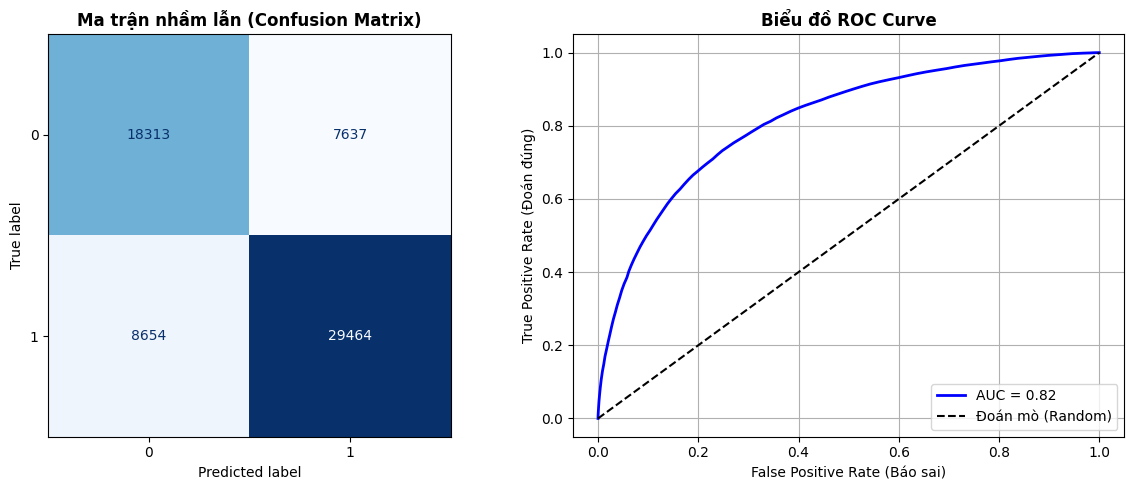

In [ ]:
# MÔ HÌNH 3: RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# 1. Khởi tạo
clf_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)

# 2. Huấn luyện
clf_rf.fit(X_train_scaled, y_train_res)

# 3. Dự đoán
y_pred_rf = clf_rf.predict(X_test_scaled)
y_proba_rf = clf_rf.predict_proba(X_test_scaled)[:, 1] # Lấy xác suất lớp 1 (Tốt)

# 4. Đánh giá chỉ số
print(classification_report(y_test, y_pred_rf))
auc_score = roc_auc_score(y_test, y_proba_rf)
print(f"ROC AUC Score: {auc_score:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, cmap='Blues', ax=ax[0], colorbar=False)
ax[0].set_title("Ma trận nhầm lẫn (Confusion Matrix)", fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, y_proba_rf)
ax[1].plot(fpr, tpr, label=f'AUC = {auc_score:.2f}', color='blue', lw=2)
ax[1].plot([0, 1], [0, 1], 'k--', label='Đoán mò (Random)') # Đường tham chiếu
ax[1].set_xlabel('False Positive Rate (Báo sai)')
ax[1].set_ylabel('True Positive Rate (Đoán đúng)')
ax[1].set_title('Biểu đồ ROC Curve', fontweight='bold')
ax[1].legend(loc='lower right')
ax[1].grid(True)

plt.tight_layout()
plt.show()

Tối ưu và chọn ngưỡng tốt nhất

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score,
                             accuracy_score, f1_score, precision_score, recall_score)
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# 2. Hàm hỗ trợ mới: Phân tích biểu đồ ngưỡng nhưng báo cáo ở ngưỡng mặc định
def analyze_and_report_default_threshold(best_model, model_name, X_test_scaled, y_test):

    # a. Lấy xác suất dự đoán
    y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

    # b.PHẦN PHÂN TÍCH: Chạy vòng lặp để vẽ biểu đồ
    thresholds = np.arange(0.0, 1.01, 0.01)
    f1_scores, precisions, recalls = [], [], []

    for t in thresholds:
        y_pred_t = (y_proba > t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
        precision_t = tp / (tp + fp + 1e-9)
        recall_t = tp / (tp + fn + 1e-9)
        f1_t = 2 * (precision_t * recall_t) / (precision_t + recall_t + 1e-9)
        f1_scores.append(f1_t); precisions.append(precision_t); recalls.append(recall_t)

    # c.PHẦN CHỐT KẾT QUẢ: Sử dụng ngưỡng mặc định 0.5
    target_threshold = 0.5
    y_pred_final = (y_proba > target_threshold).astype(int) # DỰ ĐOÁN CỐ ĐỊNH Ở 0.5

    # d. Vẽ biểu đồ kép
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    # Biểu đồ 1: Phân tích sự đánh đổi P/R/F1
    ax[0].plot(thresholds, f1_scores, label='F1 Score', color='blue', lw=2)
    ax[0].plot(thresholds, precisions, label='Precision', color='green', ls='--', alpha=0.6)
    ax[0].plot(thresholds, recalls, label='Recall', color='red', ls='--', alpha=0.6)
    ax[0].axvline(target_threshold, color='red', lw=2, label=f'Chosen Default: {target_threshold:.2f}')
    ax[0].set_title(f'{model_name} - Phân tích Ngưỡng')
    ax[0].set_xlabel('Ngưỡng (Threshold)')
    ax[0].set_ylabel('Điểm số')
    ax[0].legend(loc='lower left')
    ax[0].grid(True, alpha=0.3)

    # Biểu đồ 2: Ma trận nhầm lẫn (CỐ ĐỊNH Ở NGƯỠNG 0.5)
    cmap_color = 'Blues' if 'Random' in model_name else ('Oranges' if 'Logistic' in model_name else 'Greens')
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final, cmap=cmap_color, ax=ax[1], colorbar=False)
    ax[1].set_title(f'{model_name}\nConfusion Matrix (Threshold {target_threshold})')

    plt.tight_layout()
    plt.show()

    # e. Tính toán và in tổng hợ
    print(f"\n--- TỔNG HỢP CHỈ SỐ CUỐI CÙNG ({model_name.upper()}) ---")
    print(f"✅ Ngưỡng được chọn: {target_threshold}")
    print("-" * 40)
    final_acc = accuracy_score(y_test, y_pred_final)
    final_pre = precision_score(y_test, y_pred_final)
    final_rec = recall_score(y_test, y_pred_final)
    final_f1 = f1_score(y_test, y_pred_final)
    final_auc = roc_auc_score(y_test, y_proba)


    print("\nBáo cáo chi tiết (Tại ngưỡng 0.5):")
    report_dict = classification_report(y_test, y_pred_final, output_dict=True)
    display(pd.DataFrame(report_dict).transpose().style.background_gradient(cmap=cmap_color, subset=['f1-score']))

Random forest

1. Đang chạy Grid Search (Tìm tham số tốt nhất cho Random Forest)...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
✅ Tham số tốt nhất (Random Forest): {'criterion': 'gini', 'max_depth': 15, 'min_samples_leaf': 2, 'n_estimators': 200}


,precision,recall,f1-score,support
0,0.682296,0.723391,0.702243,25950.000000
1,0.803638,0.770686,0.786817,38118.000000
accuracy,0.751530,0.751530,0.751530,0.751530
macro avg,0.742967,0.747038,0.744530,64068.000000
weighted avg,0.754490,0.751530,0.752561,64068.000000



ROC AUC Score: 0.8229


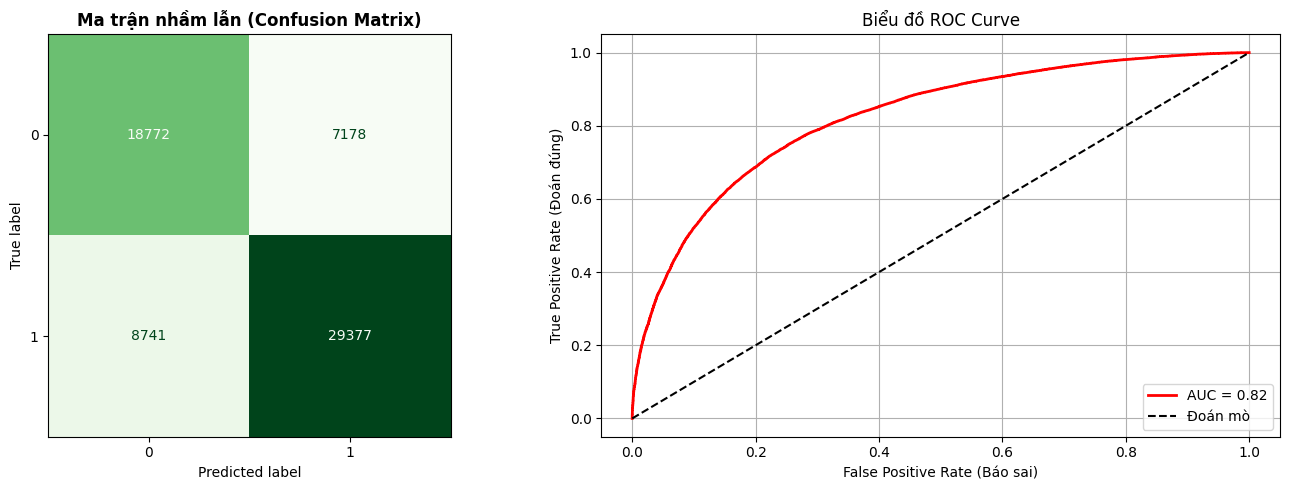

In [ ]:
#Random forest

# BƯỚC 1: Tối ưu hóa tham số (Grid Search)
print("1. Đang chạy Grid Search (Tìm tham số tốt nhất cho Random Forest)...")
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15],          # Giới hạn độ sâu vừa phải
    'min_samples_leaf': [2, 4],     # Tăng tính tổng quát
    'criterion': ['gini']
}
rf_base = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)

# Thiết lập Grid Search (Ưu tiên F1-Score)
grid_rf = GridSearchCV(estimator=rf_base, param_grid=param_grid_rf,
                       cv=3, n_jobs=-1, scoring='f1', verbose=1)
grid_rf.fit(X_train_scaled, y_train_res)

# Lưu lại mô hình có tham số tốt nhất
best_rf_final = grid_rf.best_estimator_
print(f"✅ Tham số tốt nhất (Random Forest): {grid_rf.best_params_}")

# --- BƯỚC 2: Phân tích và Báo cáo (ROC Curve và Confusion Matrix) ---
# Lấy xác suất dự đoán
y_proba_rf = best_rf_final.predict_proba(X_test_scaled)[:, 1]
# Dự đoán với ngưỡng 0.5
y_pred_rf_final = (y_proba_rf > 0.5).astype(int)

report_dict = classification_report(y_test, y_pred_rf_final, output_dict=True)
display(pd.DataFrame(report_dict).transpose().style.background_gradient(cmap='Greens', subset=['f1-score']))

auc_score_rf = roc_auc_score(y_test, y_proba_rf)
print(f"\nROC AUC Score: {auc_score_rf:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Ma trận nhầm lẫn
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf_final, cmap='Greens', ax=ax[0], colorbar=False)
ax[0].set_title("Ma trận nhầm lẫn (Confusion Matrix)", fontweight='bold')

# ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
ax[1].plot(fpr_rf, tpr_rf, label=f'AUC = {auc_score_rf:.2f}', color='red', lw=2)
ax[1].plot([0, 1], [0, 1], 'k--', label='Đoán mò')
ax[1].set_xlabel('False Positive Rate (Báo sai)')
ax[1].set_ylabel('True Positive Rate (Đoán đúng)')
ax[1].set_title('Biểu đồ ROC Curve')
ax[1].legend(loc='lower right')
ax[1].grid(True)

plt.tight_layout()
plt.show()

Mô hình logistic regression

1. Đang chạy Grid Search (Tìm tham số tốt nhất cho Logistic Regression)...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
✅ Tham số tốt nhất (Logistic Regression): {'C': 0.01, 'penalty': 'l1'}


,precision,recall,f1-score,support
0,0.696858,0.642775,0.668725,25950.000000
1,0.769012,0.809644,0.788805,38118.000000
accuracy,0.742055,0.742055,0.742055,0.742055
macro avg,0.732935,0.726209,0.728765,64068.000000
weighted avg,0.739787,0.742055,0.740168,64068.000000



ROC AUC Score: 0.8084


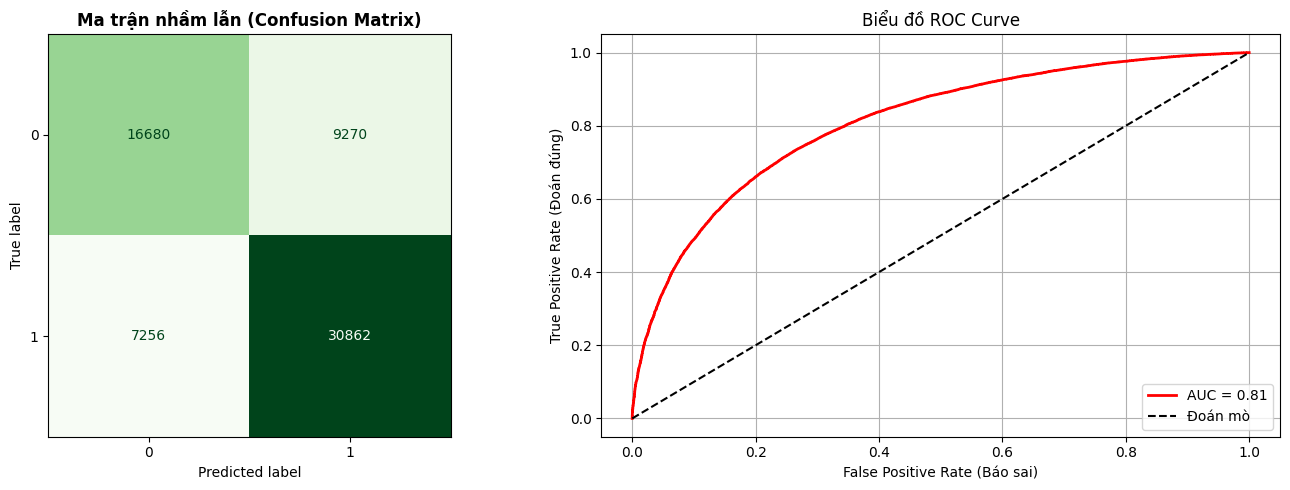

In [ ]:
# LOGISTIC REGRESSION

# BƯỚC 1: Tối ưu hóa tham số (Grid Search)
print("1. Đang chạy Grid Search (Tìm tham số tốt nhất cho Logistic Regression)...")
param_grid_log = {
    'C': [0.01, 0.1, 1, 10],   # Lực điều phạt
    'penalty': ['l1', 'l2']    # Loại điều phạt
}
# solver='liblinear' hỗ trợ cả l1 và l2 tốt cho dataset nhỏ/trung bình
log_base = LogisticRegression(random_state=42, class_weight='balanced',
                              solver='liblinear', max_iter=1000)

grid_log = GridSearchCV(estimator=log_base, param_grid=param_grid_log,
                        cv=3, n_jobs=-1, scoring='f1', verbose=1)
grid_log.fit(X_train_scaled, y_train_res)

# Lưu lại mô hình có tham số tốt nhất
best_log_final = grid_log.best_estimator_
print(f"✅ Tham số tốt nhất (Logistic Regression): {grid_log.best_params_}")

# BƯỚC 2: Phân tích và Báo cáo (ROC Curve và Confusion Matrix)
# Lấy xác suất dự đoán
y_proba_log = best_log_final.predict_proba(X_test_scaled)[:, 1]
# Dự đoán với ngưỡng 0.5
y_pred_log_final = (y_proba_log > 0.5).astype(int)

report_dict = classification_report(y_test, y_pred_log_final, output_dict=True)
display(pd.DataFrame(report_dict).transpose().style.background_gradient(cmap='Greens', subset=['f1-score']))

auc_score_log = roc_auc_score(y_test, y_proba_log)
print(f"\nROC AUC Score: {auc_score_log:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Ma trận nhầm lẫn
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log_final, cmap='Greens', ax=ax[0], colorbar=False)
ax[0].set_title("Ma trận nhầm lẫn (Confusion Matrix)", fontweight='bold')

# ROC Curve
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
ax[1].plot(fpr_log, tpr_log, label=f'AUC = {auc_score_log:.2f}', color='red', lw=2)
ax[1].plot([0, 1], [0, 1], 'k--', label='Đoán mò')
ax[1].set_xlabel('False Positive Rate (Báo sai)')
ax[1].set_ylabel('True Positive Rate (Đoán đúng)')
ax[1].set_title('Biểu đồ ROC Curve')
ax[1].legend(loc='lower right')
ax[1].grid(True)

plt.tight_layout()
plt.show()

1. Đang chạy Grid Search (Tìm tham số tốt nhất)...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
✅ Tham số tốt nhất (Decision Tree): {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2}


,precision,recall,f1-score,support
0,0.661290,0.710906,0.685201,25950.000000
1,0.792596,0.752112,0.771824,38118.000000
accuracy,0.735422,0.735422,0.735422,0.735422
macro avg,0.726943,0.731509,0.728512,64068.000000
weighted avg,0.739412,0.735422,0.736738,64068.000000



ROC AUC Score: 0.8040


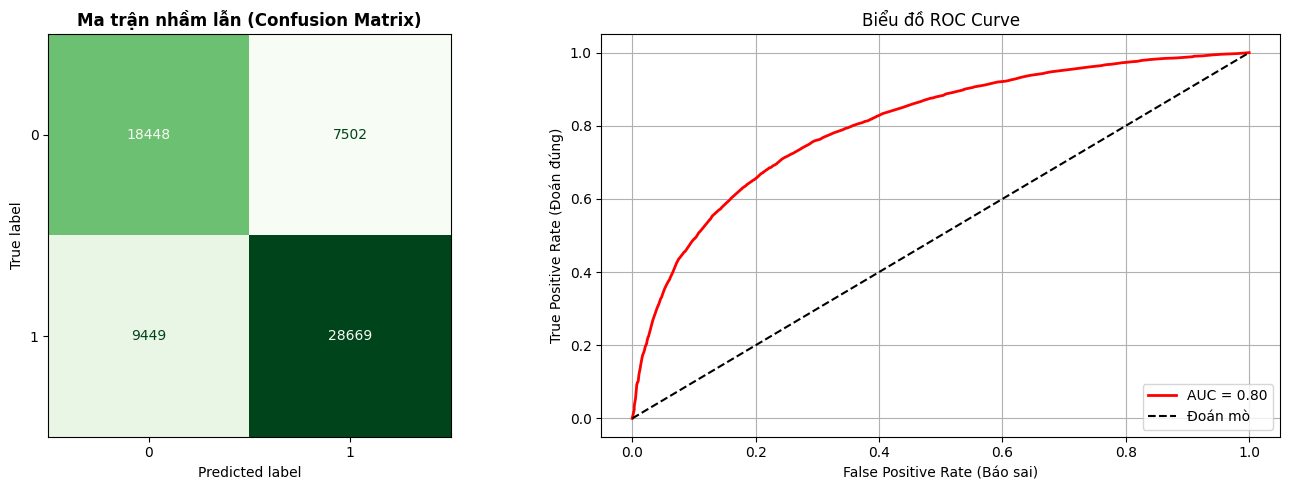

In [ ]:
# DECISION TREE
# BƯỚC 1: Tối ưu hóa tham số (Grid Search)
print("1. Đang chạy Grid Search (Tìm tham số tốt nhất)...")
param_grid_tree = {
    'max_depth': [5, 10, 15],         # Giới hạn độ sâu
    'min_samples_leaf': [2, 4, 8],    # Tăng tính tổng quát
    'criterion': ['gini', 'entropy']
}
tree_base = DecisionTreeClassifier(random_state=42, class_weight='balanced')

grid_tree = GridSearchCV(estimator=tree_base, param_grid=param_grid_tree,
                         cv=3, n_jobs=-1, scoring='f1', verbose=1)
grid_tree.fit(X_train_scaled, y_train_res)

best_tree_final = grid_tree.best_estimator_
print(f"✅ Tham số tốt nhất (Decision Tree): {grid_tree.best_params_}")

# BƯỚC 2: Phân tích và Báo cáo
# Lấy xác suất dự đoán
y_proba_tree = best_tree_final.predict_proba(X_test_scaled)[:, 1]
# Dự đoán với ngưỡng 0.5
y_pred_tree_final = (y_proba_tree > 0.5).astype(int)

report_dict = classification_report(y_test, y_pred_tree_final, output_dict=True)
display(pd.DataFrame(report_dict).transpose().style.background_gradient(cmap='Greens', subset=['f1-score']))

auc_score_tree = roc_auc_score(y_test, y_proba_tree)
print(f"\nROC AUC Score: {auc_score_tree:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Ma trận nhầm lẫn
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree_final, cmap='Greens', ax=ax[0], colorbar=False)
ax[0].set_title("Ma trận nhầm lẫn (Confusion Matrix)", fontweight='bold')

# ROC Curve
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_proba_tree)
ax[1].plot(fpr_tree, tpr_tree, label=f'AUC = {auc_score_tree:.2f}', color='red', lw=2)
ax[1].plot([0, 1], [0, 1], 'k--', label='Đoán mò')
ax[1].set_xlabel('False Positive Rate (Báo sai)')
ax[1].set_ylabel('True Positive Rate (Đoán đúng)')
ax[1].set_title('Biểu đồ ROC Curve')
ax[1].legend(loc='lower right')
ax[1].grid(True)

plt.tight_layout()
plt.show()

BẢNG SO SÁNH CÁC MÔ HÌNH Ở NGƯỠNG 0.5


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,TN,FP,FN,TP
0,Random Forest,0.7515,0.8036,0.7707,0.7868,0.8229,18772,7178,8741,29377
1,Logistic Regression,0.7421,0.7690,0.8096,0.7888,0.8084,16680,9270,7256,30862
2,Decision Tree,0.7355,0.7922,0.7530,0.7721,0.8040,18422,7528,9417,28701


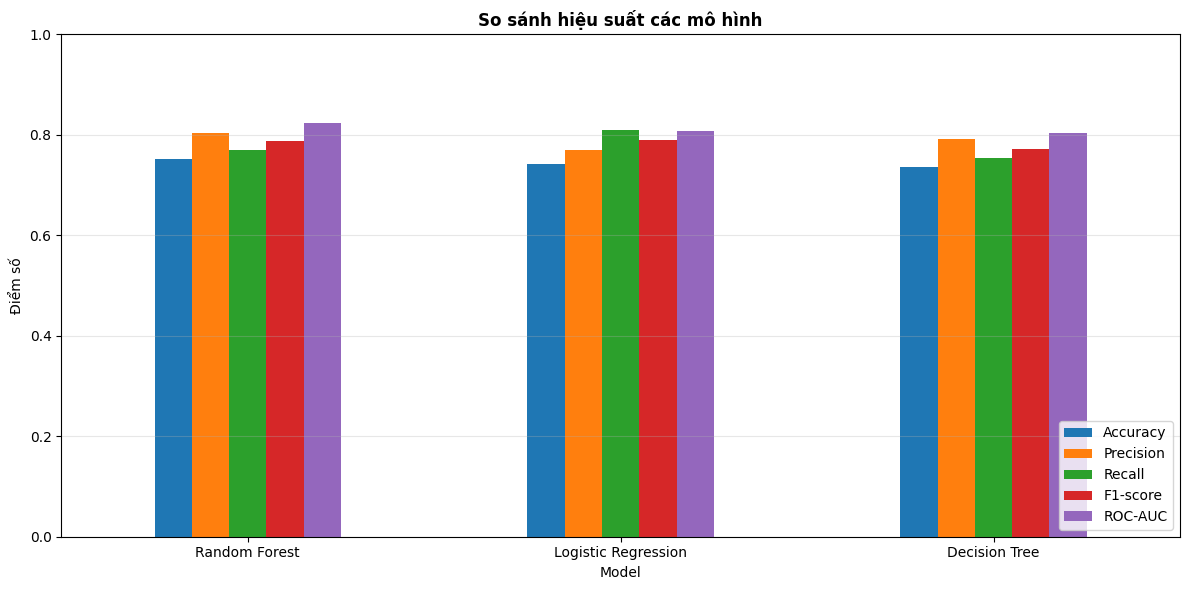

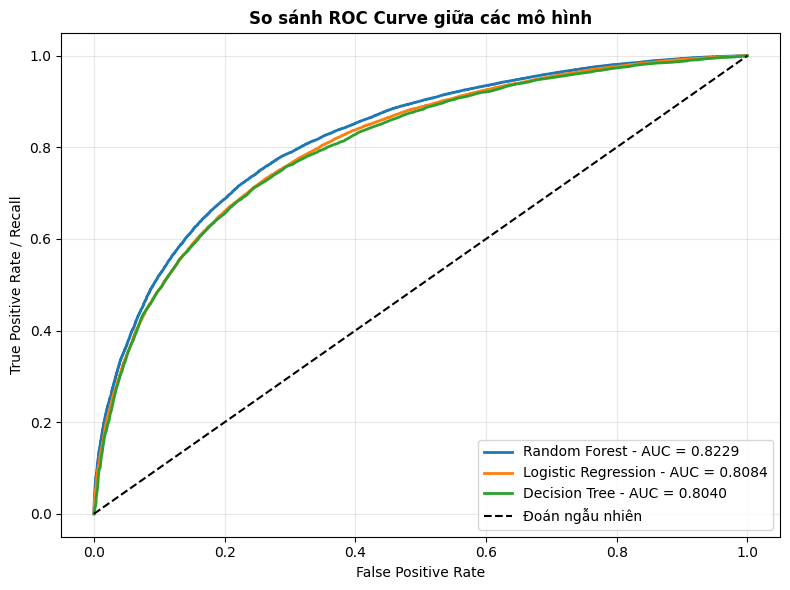


KẾT LUẬN SO SÁNH
Mô hình tốt nhất theo ROC-AUC: Random Forest
ROC-AUC: 0.8229
F1-score: 0.7868
Recall: 0.7707
Precision: 0.8036

Gợi ý lựa chọn:
- Nếu ưu tiên khả năng phân biệt tổng thể: chọn Random Forest vì ROC-AUC cao nhất.
- Nếu ưu tiên cân bằng Precision và Recall: chọn Logistic Regression vì F1-score cao nhất.
- Nếu ưu tiên bắt được nhiều review điểm cao nhất: chọn Logistic Regression vì Recall cao nhất.


In [ ]:

# 1. Gom các mô hình đã train vào một dictionary
models_to_compare = {}

if 'best_rf_final' in globals():
    models_to_compare['Random Forest'] = best_rf_final
elif 'clf_rf' in globals():
    models_to_compare['Random Forest'] = clf_rf

if 'best_log_final' in globals():
    models_to_compare['Logistic Regression'] = best_log_final
elif 'clf_log' in globals():
    models_to_compare['Logistic Regression'] = clf_log

if 'best_tree_final' in globals():
    models_to_compare['Decision Tree'] = best_tree_final
elif 'clf_tree' in globals():
    models_to_compare['Decision Tree'] = clf_tree

if len(models_to_compare) == 0:
    raise ValueError('Chưa tìm thấy mô hình nào. Hãy chạy các cell train model trước khi chạy phần so sánh.')

# 2. Tính các chỉ số đánh giá cho từng mô hình
comparison_results = []
roc_data = {}
confusion_results = {}

THRESHOLD = 0.5

for model_name, model in models_to_compare.items():
    # Lấy xác suất lớp 1 nếu model có predict_proba
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        # Dự phòng cho model không có predict_proba
        y_score = model.decision_function(X_test_scaled)
        y_proba = (y_score - y_score.min()) / (y_score.max() - y_score.min())

    y_pred = (y_proba >= THRESHOLD).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    comparison_results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'TP': tp
    })

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[model_name] = (fpr, tpr, roc_auc_score(y_test, y_proba))
    confusion_results[model_name] = np.array([[tn, fp], [fn, tp]])

comparison_df = pd.DataFrame(comparison_results)
comparison_df = comparison_df.sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)

print('BẢNG SO SÁNH CÁC MÔ HÌNH Ở NGƯỠNG 0.5')
display(
    comparison_df.style
    .format({
        'Accuracy': '{:.4f}',
        'Precision': '{:.4f}',
        'Recall': '{:.4f}',
        'F1-score': '{:.4f}',
        'ROC-AUC': '{:.4f}'
    })
    .background_gradient(cmap='Greens', subset=['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC'])
)

# 3. Vẽ biểu đồ so sánh các metric chính

metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']
plot_df = comparison_df.set_index('Model')[metric_cols]

ax = plot_df.plot(kind='bar', figsize=(12, 6))
plt.title('So sánh hiệu suất các mô hình', fontweight='bold')
plt.ylabel('Điểm số')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Vẽ ROC Curve của tất cả mô hình trên cùng một biểu đồ

plt.figure(figsize=(8, 6))
for model_name, (fpr, tpr, auc_score) in roc_data.items():
    plt.plot(fpr, tpr, lw=2, label=f'{model_name} - AUC = {auc_score:.4f}')

plt.plot([0, 1], [0, 1], 'k--', label='Đoán ngẫu nhiên')
plt.title('So sánh ROC Curve giữa các mô hình', fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate / Recall')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Tự động chọn mô hình tốt nhất
best_row = comparison_df.iloc[0]
print('\nKẾT LUẬN SO SÁNH')
print(f"Mô hình tốt nhất theo ROC-AUC: {best_row['Model']}")
print(f"ROC-AUC: {best_row['ROC-AUC']:.4f}")
print(f"F1-score: {best_row['F1-score']:.4f}")
print(f"Recall: {best_row['Recall']:.4f}")
print(f"Precision: {best_row['Precision']:.4f}")

# Gợi ý cách chọn mô hình theo mục tiêu bài toán
best_f1_model = comparison_df.sort_values(by='F1-score', ascending=False).iloc[0]
best_recall_model = comparison_df.sort_values(by='Recall', ascending=False).iloc[0]

print('\nGợi ý lựa chọn:')
print(f"- Nếu ưu tiên khả năng phân biệt tổng thể: chọn {best_row['Model']} vì ROC-AUC cao nhất.")
print(f"- Nếu ưu tiên cân bằng Precision và Recall: chọn {best_f1_model['Model']} vì F1-score cao nhất.")
print(f"- Nếu ưu tiên bắt được nhiều review điểm cao nhất: chọn {best_recall_model['Model']} vì Recall cao nhất.")



In [ ]:
# TEST THỬ 5 MẪU NGẪU NHIÊN
# Mỗi lần chạy sẽ lấy 5 mẫu khác nhau vì không đặt random_state

# Ưu tiên dùng mô hình Random Forest đã tối ưu nếu có, nếu chưa có thì dùng clf_rf
if 'best_rf_final' in globals():
    final_model = best_rf_final
    model_name = 'Random Forest sau GridSearchCV'
elif 'clf_rf' in globals():
    final_model = clf_rf
    model_name = 'Random Forest cơ bản'
else:
    raise ValueError('Chưa có mô hình Random Forest. Hãy chạy cell train Random Forest trước.')

# Lấy ngẫu nhiên 5 mẫu từ tập test gốc
sample_X = X_test.sample(n=5)
sample_y = y_test.loc[sample_X.index]

# Scale dữ liệu giống lúc train
sample_X_scaled = scaler.transform(sample_X)

# Dự đoán
sample_pred = final_model.predict(sample_X_scaled)
sample_proba = final_model.predict_proba(sample_X_scaled)[:, 1]

# Tạo bảng kết quả dễ xem
result_5_random = sample_X.copy()
result_5_random['Thực tế'] = sample_y.values
result_5_random['Dự đoán'] = sample_pred
result_5_random['Xác suất High Score'] = sample_proba

# Đổi nhãn số sang chữ cho dễ hiểu
label_map = {
    0: 'Không High Score',
    1: 'High Score'
}
result_5_random['Thực tế_label'] = result_5_random['Thực tế'].map(label_map)
result_5_random['Dự đoán_label'] = result_5_random['Dự đoán'].map(label_map)

print(f'Mô hình dùng để test: {model_name}')
print('Kết quả dự đoán 5 mẫu ngẫu nhiên:')
display(result_5_random[['Thực tế_label', 'Dự đoán_label', 'Xác suất High Score']])


Mô hình dùng để test: Random Forest sau GridSearchCV
Kết quả dự đoán 5 mẫu ngẫu nhiên:


,Thực tế_label,Dự đoán_label,Xác suất High Score
276548,Không High Score,Không High Score,0.449740
68015,Không High Score,High Score,0.884403
32013,Không High Score,Không High Score,0.278402
51057,Không High Score,Không High Score,0.280238
25109,High Score,High Score,0.617923
